# Patient Risk Prediction System

---
**Goal:** Build a clean, reproducible preprocessing pipeline,
zero→NaN replacement · median imputation · feature scaling ·
stratified train/test split · save outputs for Notebook 4.

## Cell 1 · Imports, Data Load & Config

In [2]:
##%%
#  Standard library
import os
import pickle
import warnings
warnings.filterwarnings('ignore')

#  Load Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mc
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import StandardScaler
from sklearn.impute           import SimpleImputer
from sklearn.pipeline         import Pipeline

# Palette
PRIMARY = '#1D4ED8'
ACCENT  = '#06B6D4'
BG      = '#EEF4FF'
CARD    = '#FFFFFF'
BORDER  = '#C7D9F0'
TEXT    = '#0F172A'
MUTED   = '#475569'
SUCCESS = '#0D9488'
DANGER  = '#EF4444'

plt.rcParams.update({
    'figure.facecolor' : BG,
    'axes.facecolor'   : CARD,
    'axes.edgecolor'   : BORDER,
    'axes.labelcolor'  : TEXT,
    'xtick.color'      : MUTED,
    'ytick.color'      : MUTED,
    'text.color'       : TEXT,
    'grid.color'       : '#DCE7F7',
    'grid.linewidth'   : 0.6,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.size'        : 10,
})

#  Output folder
OUTPUT_DIR = 'outputs/figures'
os.makedirs(OUTPUT_DIR, exist_ok=True)

#  Constants
DATA_PATH = 'diabetes.csv'      # ← update path if needed
ZERO_COLS = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
RANDOM_STATE = 42
TEST_SIZE    = 0.20

#  Load raw data
df_raw = pd.read_csv("C:\\Users\\PC\\Downloads\\archive (8)\\diabetes.csv")

FEATURE_NAMES = [c for c in df_raw.columns if c != 'Outcome']

print("✓ All imports loaded")
print(f"✓ Data loaded: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns")
print(f"✓ Features   : {FEATURE_NAMES}")
print(f"✓ Output dir : {os.path.abspath(OUTPUT_DIR)}")
print()
print("First 5 rows:")
print(df_raw.head().to_string())


✓ All imports loaded
✓ Data loaded: 768 rows × 9 columns
✓ Features   : ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
✓ Output dir : C:\Users\PC\PycharmProjects\prediction_cost\outputs\figures

First 5 rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  DiabetesPedigreeFunction  Age  Outcome
0            6      148             72             35        0  33.6                     0.627   50        1
1            1       85             66             29        0  26.6                     0.351   31        0
2            8      183             64              0        0  23.3                     0.672   32        1
3            1       89             66             23       94  28.1                     0.167   21        0
4            0      137             40             35      168  43.1                     2.288   33        1


## Cell 2 · Inspect Raw Data


In [3]:
##%%
print("Shape:", df_raw.shape)
print()
print("Data types:")
print(df_raw.dtypes.to_string())
print()
print("Statistical summary:")
print(df_raw.describe().round(2).to_string())


Shape: (768, 9)

Data types:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64

Statistical summary:
       Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin     BMI  DiabetesPedigreeFunction     Age  Outcome
count       768.00   768.00         768.00         768.00   768.00  768.00                    768.00  768.00   768.00
mean          3.85   120.89          69.11          20.54    79.80   31.99                      0.47   33.24     0.35
std           3.37    31.97          19.36          15.95   115.24    7.88                      0.33   11.76     0.48
min           0.00     0.00           0.00           0.00     0.00    0.00                      0.08   21.00     0.00
25%           1.00    99.00        

## Cell 3 · Zero-as-Missing Analysis

**missing data encoded as 0**. We replace them with `NaN` before imputing.


In [4]:
##%%
#  Analyse zeros BEFORE replacement
print("Zero-as-missing analysis (raw data):")
print("-" * 52)

zero_report = []
for col in ZERO_COLS:
    n_zeros = (df_raw[col] == 0).sum()
    pct     = n_zeros / len(df_raw) * 100
    severity = 'HIGH' if pct > 20 else 'MEDIUM' if pct > 5 else 'LOW'
    zero_report.append({
        'Feature'   : col,
        'Zero Count': n_zeros,
        'Zero %'    : f'{pct:.1f}%',
        'Severity'  : severity,
        'Action'    : 'Replace with NaN → median impute'
    })
    print(f"  {col:<20} zeros={n_zeros:>3}  ({pct:.1f}%)  [{severity}]")

print()
print("Columns with no zero issues (kept as-is):")
safe_cols = [c for c in FEATURE_NAMES if c not in ZERO_COLS]
for col in safe_cols:
    print(f"  {col:<20} ✓ no zero issue")


Zero-as-missing analysis (raw data):
----------------------------------------------------
  Glucose              zeros=  5  (0.7%)  [LOW]
  BloodPressure        zeros= 35  (4.6%)  [LOW]
  SkinThickness        zeros=227  (29.6%)  [HIGH]
  Insulin              zeros=374  (48.7%)  [HIGH]
  BMI                  zeros= 11  (1.4%)  [LOW]

Columns with no zero issues (kept as-is):
  Pregnancies          ✓ no zero issue
  DiabetesPedigreeFunction ✓ no zero issue
  Age                  ✓ no zero issue


## Cell 4 · Replace Impossible Zeros with NaN

In [5]:
##%%
#  Create working copy & replace zeros
df = df_raw.copy()
df[ZERO_COLS] = df[ZERO_COLS].replace(0, np.nan)

#  Verify: zeros gone, NaN appeared
before_zeros = df_raw[ZERO_COLS].eq(0).sum().rename('Zeros Before')
after_nans   = df[ZERO_COLS].isnull().sum().rename('NaN After')

comparison = pd.concat([before_zeros, after_nans], axis=1)
print("Verification — zeros replaced by NaN:")
print(comparison.to_string())
print()
print(f"Total NaN in working dataset : {df.isnull().sum().sum()}")
print("✓ Zero-to-NaN replacement complete")


Verification — zeros replaced by NaN:
               Zeros Before  NaN After
Glucose                   5          5
BloodPressure            35         35
SkinThickness           227        227
Insulin                 374        374
BMI                      11         11

Total NaN in working dataset : 652
✓ Zero-to-NaN replacement complete


## Cell 5 · Separate Features (X) and Target (y)

In [6]:
##%%
X = df.drop('Outcome', axis=1)
y = df['Outcome']

print(f"X shape : {X.shape}  (features)")
print(f"y shape : {y.shape}  (target)")
print()
print("Target value counts:")
print(y.value_counts().rename('Count').to_frame().assign(
    Percent=lambda d: (d['Count'] / len(y) * 100).round(1).astype(str) + '%'
).to_string())


X shape : (768, 8)  (features)
y shape : (768,)  (target)

Target value counts:
         Count Percent
Outcome               
0          500   65.1%
1          268   34.9%


## Cell 6 · Stratified Train / Test Split (80 / 20)

In [7]:
##%%
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = TEST_SIZE,
    random_state = RANDOM_STATE,
    stratify     = y           # preserves class ratio in both sets
)

print(f"Training set : {X_train.shape[0]} samples")
print(f"Test set     : {X_test.shape[0]} samples")
print()

# Confirm stratification worked
for name, y_split in [('Train', y_train), ('Test', y_test)]:
    vc = y_split.value_counts(normalize=True).mul(100).round(1)
    print(f"{name} class balance → No Diabetes: {vc[0]}%  |  Diabetes: {vc[1]}%")


Training set : 614 samples
Test set     : 154 samples

Train class balance → No Diabetes: 65.1%  |  Diabetes: 34.9%
Test class balance → No Diabetes: 64.9%  |  Diabetes: 35.1%


## Cell 7 · Median Imputation

> **Key rule:** Fit the imputer **only on training data**, then apply
> (transform) to both train and test.
> Fitting on all data would leak test information into training — invalidating evaluation.


In [8]:
##%%
# Fit imputer on TRAINING DATA ONLY
imputer = SimpleImputer(strategy='median')
imputer.fit(X_train)

#  Transform both sets
X_train_imp = pd.DataFrame(
    imputer.transform(X_train),
    columns=FEATURE_NAMES,
    index=X_train.index
)
X_test_imp = pd.DataFrame(
    imputer.transform(X_test),
    columns=FEATURE_NAMES,
    index=X_test.index
)

#  Show the median values used for imputation
medians_used = pd.DataFrame({
    'Feature'         : FEATURE_NAMES,
    'Median Used'     : imputer.statistics_.round(3),
    'Was Zero Column' : ['YES' if c in ZERO_COLS else 'no' for c in FEATURE_NAMES]
})
print("Medians learned from training data:")
print(medians_used.to_string(index=False))
print()
print(f"NaN remaining — Train: {X_train_imp.isnull().sum().sum()}")
print(f"NaN remaining — Test : {X_test_imp.isnull().sum().sum()}")
print("✓ Imputation complete — no missing values remain")


Medians learned from training data:
                 Feature  Median Used Was Zero Column
             Pregnancies        3.000              no
                 Glucose      117.000             YES
           BloodPressure       72.000             YES
           SkinThickness       29.000             YES
                 Insulin      125.000             YES
                     BMI       32.400             YES
DiabetesPedigreeFunction        0.382              no
                     Age       29.000              no

NaN remaining — Train: 0
NaN remaining — Test : 0
✓ Imputation complete — no missing values remain


## Cell 8 · Standard Scaling

Logistic Regression requires scaling. Tree-based models don't,
but we scale for all models so the pipeline is consistent.


In [9]:
##%%
#  Fit scaler on imputed TRAINING DATA ONLY
scaler = StandardScaler()
scaler.fit(X_train_imp)

X_train_scaled = pd.DataFrame(
    scaler.transform(X_train_imp),
    columns=FEATURE_NAMES,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_imp),
    columns=FEATURE_NAMES,
    index=X_test.index
)

print("Feature statistics after StandardScaler (train set):")
print(X_train_scaled.describe().T[['mean', 'std', 'min', 'max']].round(3).to_string())
print()
print("✓ All features → mean ≈ 0.000, std ≈ 1.000")


Feature statistics after StandardScaler (train set):
                          mean    std    min    max
Pregnancies               -0.0  1.001 -1.153  3.980
Glucose                   -0.0  1.001 -2.191  2.579
BloodPressure              0.0  1.001 -3.925  4.065
SkinThickness             -0.0  1.001 -2.481  7.874
Insulin                   -0.0  1.001 -1.559  7.704
BMI                        0.0  1.001 -2.090  5.082
DiabetesPedigreeFunction  -0.0  1.001 -1.192  5.610
Age                       -0.0  1.001 -1.046  4.029

✓ All features → mean ≈ 0.000, std ≈ 1.000


## Cell 9 · Visualise: Before vs After Scaling


IndexError: index 4 is out of bounds for axis 0 with size 4

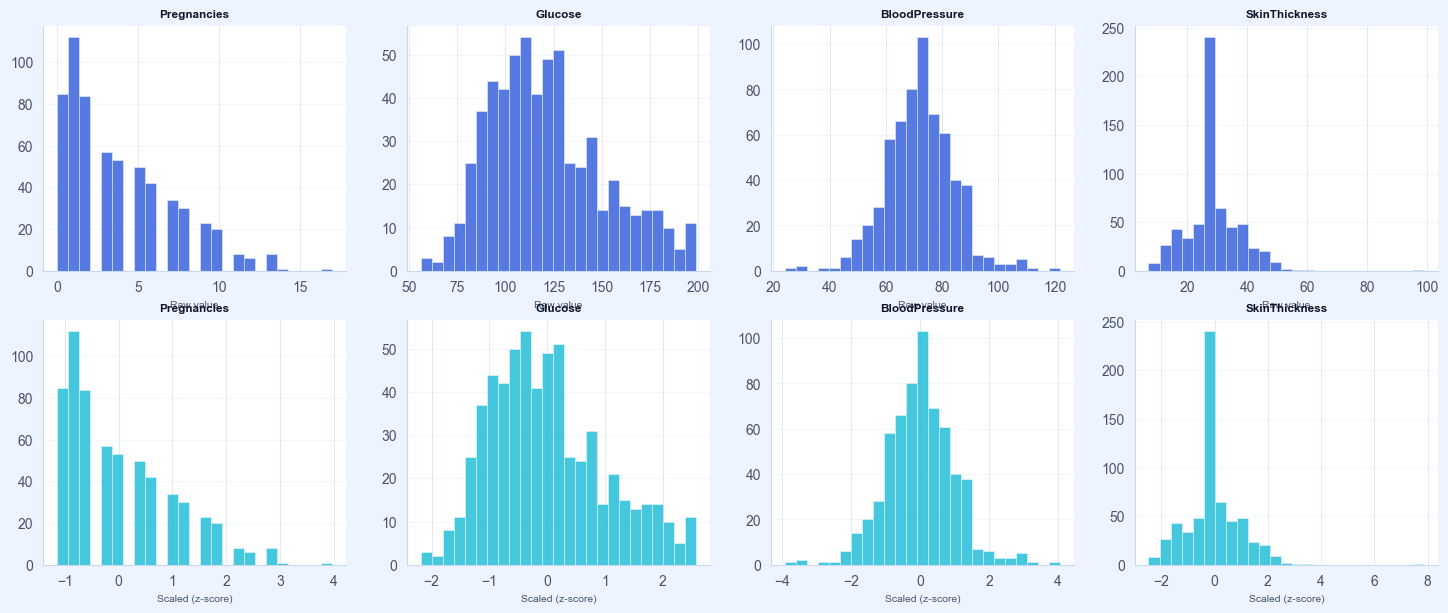

In [11]:
##%%
import os
import pickle
import warnings
warnings.filterwarnings('ignore')

CMAP = mc.LinearSegmentedColormap.from_list('ocean', [PRIMARY, ACCENT])

fig, axes = plt.subplots(2, 4, figsize=(18, 7), facecolor=BG)

for idx, feat in enumerate(FEATURE_NAMES):
    ax_raw    = axes[0][idx]
    ax_scaled = axes[1][idx]

    ax_raw.hist(X_train_imp[feat], bins=25, color=PRIMARY,
                alpha=0.75, edgecolor='white', linewidth=0.4)
    ax_raw.set_title(feat, fontsize=8.5, fontweight='bold')
    ax_raw.set_xlabel('Raw value', fontsize=7.5, color=MUTED)
    ax_raw.yaxis.grid(True, alpha=0.4)
    ax_raw.set_axisbelow(True)

    ax_scaled.hist(X_train_scaled[feat], bins=25, color=ACCENT,
                   alpha=0.75, edgecolor='white', linewidth=0.4)
    ax_scaled.set_title(feat, fontsize=8.5, fontweight='bold')
    ax_scaled.set_xlabel('Scaled (z-score)', fontsize=7.5, color=MUTED)
    ax_scaled.yaxis.grid(True, alpha=0.4)
    ax_scaled.set_axisbelow(True)

axes[0][0].set_ylabel('Count — Raw',    fontsize=9, color=MUTED)
axes[1][0].set_ylabel('Count — Scaled', fontsize=9, color=MUTED)

plt.suptitle('Feature Distributions: Before vs After StandardScaler',
             fontsize=13, fontweight='bold', y=1.01, color=TEXT)
plt.tight_layout()

save_path = os.path.join(OUTPUT_DIR, 'prep_01_before_after_scaling.png')
fig.savefig(save_path, dpi=150, bbox_inches='tight', facecolor=BG)
print(f"Saved → {save_path}")
plt.show()


## Cell 10 · Missing Values: Before vs After Imputation


Saved → outputs/figures\prep_02_missing_before_after.png


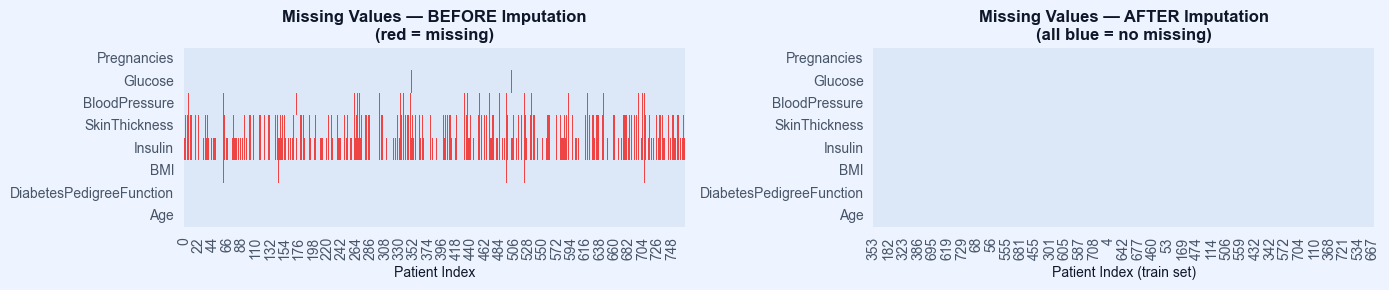

In [12]:
##%%
fig, axes = plt.subplots(1, 2, figsize=(14, 3), facecolor=BG)

# Before imputation
before_missing = df[FEATURE_NAMES].isnull().astype(int)
sns.heatmap(before_missing.T, cmap=['#DCE7F7', DANGER],
            cbar=False, ax=axes[0], yticklabels=FEATURE_NAMES,
            linewidths=0, rasterized=True)
axes[0].set_title('Missing Values — BEFORE Imputation\n(red = missing)',
                  fontweight='bold')
axes[0].set_xlabel('Patient Index')

# After imputation
after_missing = X_train_imp.isnull().astype(int)
sns.heatmap(after_missing.T, cmap=['#DCE7F7', DANGER],
            cbar=False, ax=axes[1], yticklabels=FEATURE_NAMES,
            linewidths=0, rasterized=True)
axes[1].set_title('Missing Values — AFTER Imputation\n(all blue = no missing)',
                  fontweight='bold')
axes[1].set_xlabel('Patient Index (train set)')

plt.tight_layout()
save_path = os.path.join(OUTPUT_DIR, 'prep_02_missing_before_after.png')
fig.savefig(save_path, dpi=150, bbox_inches='tight', facecolor=BG)
print(f"Saved → {save_path}")
plt.show()


## Cell 11 · Build Reusable sklearn Pipeline

A **Pipeline** ensures the imputer and scaler are always applied
consistently; both during cross-validation and final prediction.

 The classifier is plugged in during Notebook 4.
 Here we define the preprocessing steps only


In [13]:
##%%


preprocessing_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    # ('classifier', LogisticRegression())   ← added in Notebook 4
])

print("Preprocessing pipeline:")
for step_name, step_obj in preprocessing_pipeline.steps:
    print(f"  [{step_name}]  →  {type(step_obj).__name__}")

print()
print("To add a classifier in Notebook 4, use:")
print("  Pipeline([('imputer', ...), ('scaler', ...), ('clf', YourModel())])")


Preprocessing pipeline:
  [imputer]  →  SimpleImputer
  [scaler]  →  StandardScaler

To add a classifier in Notebook 4, use:
  Pipeline([('imputer', ...), ('scaler', ...), ('clf', YourModel())])


## Cell 12 · Save All Objects for Notebook 4

We save every split array and both fitted transformers into a single
`.pkl` file so Notebook 4 can load everything with one line.


In [14]:
##%%
os.makedirs('outputs', exist_ok=True)

save_dict = {
    'X_train'        : X_train_imp,      # imputed, NOT scaled
    'X_test'         : X_test_imp,
    'X_train_scaled' : X_train_scaled,   # imputed AND scaled
    'X_test_scaled'  : X_test_scaled,
    'y_train'        : y_train,
    'y_test'         : y_test,
    'imputer'        : imputer,
    'scaler'         : scaler,
    'feature_names'  : FEATURE_NAMES,
}

SAVE_PATH = 'preprocessed_data.pkl'
with open(SAVE_PATH, 'wb') as f:
    pickle.dump(save_dict, f)

size_kb = os.path.getsize(SAVE_PATH) / 1024
print(f"✓ Saved: {os.path.abspath(SAVE_PATH)}  ({size_kb:.1f} KB)")
print()
print("Contents of preprocessed_data.pkl:")
for key, val in save_dict.items():
    if hasattr(val, 'shape'):
        print(f"  '{key}' → shape {val.shape}")
    elif hasattr(val, '__len__'):
        print(f"  '{key}' → {len(val)} items")
    else:
        print(f"  '{key}' → {type(val).__name__}")

print()
print("Load in Notebook 4 with:")
print("  import pickle")
print("  with open('preprocessed_data.pkl', 'rb') as f:")
print("      data = pickle.load(f)")


✓ Saved: C:\Users\PC\PycharmProjects\prediction_cost\preprocessed_data.pkl  (123.0 KB)

Contents of preprocessed_data.pkl:
  'X_train' → shape (614, 8)
  'X_test' → shape (154, 8)
  'X_train_scaled' → shape (614, 8)
  'X_test_scaled' → shape (154, 8)
  'y_train' → shape (614,)
  'y_test' → shape (154,)
  'imputer' → SimpleImputer
  'scaler' → StandardScaler
  'feature_names' → 8 items

Load in Notebook 4 with:
  import pickle
  with open('preprocessed_data.pkl', 'rb') as f:
      data = pickle.load(f)


## ✅ Notebook 3 Complete

| Step | What happened | Output |
|---|---|---|
| Cell 1 | Imports + data loaded | `df_raw` |
| Cell 2 | Raw data inspected | — |
| Cell 3 | Zeros audited | — |
| Cell 4 | Zeros → NaN | `df` |
| Cell 5 | X / y separated | `X`, `y` |
| Cell 6 | 80/20 stratified split | `X_train`, `X_test`, `y_train`, `y_test` |
| Cell 7 | Median imputation (train-only fit) | `X_train_imp`, `X_test_imp` |
| Cell 8 | Standard scaling (train-only fit) | `X_train_scaled`, `X_test_scaled` |
| Cell 9 | Before/after scaling plots | `prep_01_...png` |
| Cell 10 | Missing value heatmaps | `prep_02_...png` |
| Cell 11 | Reusable Pipeline built | `preprocessing_pipeline` |
| Cell 12 | Everything saved | `preprocessed_data.pkl` |
